In [1]:
#1 Preparando el rancho (entorno)
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import ast

sns.set(style="whitegrid")


In [2]:
#2 Cargando datos
link_telecomx = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

respuesta_telecomx = requests.get(link_telecomx)
datos_telecomx = respuesta_telecomx.json()

corral_manada_bruta = pd.DataFrame(datos_telecomx)

corral_manada_bruta.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [3]:
#3 Vistazo a la manada sucia
print("Tamaño del corral:", corral_manada_bruta.shape)
print("\nColumnas del corral:")
print(corral_manada_bruta.columns)
print("\nInfo del corral:")
corral_manada_bruta.info()


Tamaño del corral: (7267, 6)

Columnas del corral:
Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object')

Info del corral:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [4]:
#4 Manada aseada (sin clones ni huecos)
manada_aseada = corral_manada_bruta.copy()

for col in manada_aseada.columns:
    if manada_aseada[col].apply(lambda x: isinstance(x, (dict, list))).any():
        manada_aseada[col] = manada_aseada[col].astype(str)

print("Duplicados en la manada:", manada_aseada.duplicated().sum())
manada_aseada = manada_aseada.drop_duplicates()

print("\nNulos por columna en la manada:")
print(manada_aseada.isna().sum())


Duplicados en la manada: 0

Nulos por columna en la manada:
customerID    0
Churn         0
customer      0
phone         0
internet      0
account       0
dtype: int64


In [5]:
#5 Dinero de la manada y quién deja de pagar
def a_diccionario_bestia(x):
    if isinstance(x, dict):
        return x
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return None
    return None

manada_aseada["ficha_cuenta"] = corral_manada_bruta["account"].apply(a_diccionario_bestia)

def sacar_dinero(f):
    if isinstance(f, dict):
        charges = f.get("Charges")
        if isinstance(charges, dict):
            return charges.get("Monthly"), charges.get("Total")
    return None, None

manada_aseada[["pago_mensual","pago_total"]] = manada_aseada["ficha_cuenta"].apply(
    lambda f: pd.Series(sacar_dinero(f))
)

manada_aseada["pago_mensual"] = pd.to_numeric(manada_aseada["pago_mensual"], errors="coerce")
manada_aseada["pago_total"] = pd.to_numeric(manada_aseada["pago_total"], errors="coerce")

mediana_pago = manada_aseada["pago_mensual"].median()
manada_aseada["pago_mensual"] = manada_aseada["pago_mensual"].fillna(mediana_pago)

manada_aseada["pago_por_dia"] = manada_aseada["pago_mensual"] / 30

manada_aseada["Churn"] = manada_aseada["Churn"].astype(str).str.strip().str.lower()
mapa_churn = {"yes":1,"si":1,"sí":1,"1":1,"true":1,
              "no":0,"0":0,"false":0}
manada_aseada["deja_de_pagar"] = manada_aseada["Churn"].map(mapa_churn)

manada_aseada[["customerID","deja_de_pagar","pago_mensual","pago_total","pago_por_dia"]].head()


,customerID,deja_de_pagar,pago_mensual,pago_total,pago_por_dia
0,0002-ORFBO,0.0,65.6,593.30,2.186667
1,0003-MKNFE,0.0,59.9,542.40,1.996667
2,0004-TLHLJ,1.0,73.9,280.85,2.463333
3,0011-IGKFF,1.0,98.0,1237.85,3.266667
4,0013-EXCHZ,1.0,83.9,267.40,2.796667


In [6]:
#6 Resumen del billete de la manada
manada_aseada[["pago_mensual","pago_total","pago_por_dia"]].describe()


,pago_mensual,pago_total,pago_por_dia
count,7267.000000,7256.000000,7267.000000
mean,64.720098,2280.634213,2.157337
std,30.129572,2268.632997,1.004319
min,18.250000,18.800000,0.608333
25%,35.425000,400.225000,1.180833
50%,70.300000,1391.000000,2.343333
75%,89.875000,3785.300000,2.995833
max,118.750000,8684.800000,3.958333


In [7]:
#7 Tasa de bueyes que dejan de pagar
manada_aseada["deja_de_pagar"].value_counts(), manada_aseada["deja_de_pagar"].mean()


(deja_de_pagar
 0.0    5174
 1.0    1869
 Name: count, dtype: int64,
 np.float64(0.2653698707936959))

In [8]:
#8 ¿Cuánto pagan en promedio los que se van vs los que se quedan?
manada_aseada.groupby("deja_de_pagar")[["pago_mensual","pago_total","pago_por_dia"]].mean()


,pago_mensual,pago_total,pago_por_dia
deja_de_pagar,,,
0.0,61.265124,2555.344141,2.042171
1.0,74.441332,1531.796094,2.481378


In [9]:
#9 Ver columnas actuales
manada_aseada.columns


Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account',
       'ficha_cuenta', 'pago_mensual', 'pago_total', 'pago_por_dia',
       'deja_de_pagar'],
      dtype='object')

In [10]:
#10 Sacar columnas de contrato desde ficha_cuenta
manada_aseada["Contract"] = manada_aseada["ficha_cuenta"].apply(
    lambda d: d.get("Contract") if isinstance(d, dict) else None
)
manada_aseada["PaperlessBilling"] = manada_aseada["ficha_cuenta"].apply(
    lambda d: d.get("PaperlessBilling") if isinstance(d, dict) else None
)
manada_aseada["PaymentMethod"] = manada_aseada["ficha_cuenta"].apply(
    lambda d: d.get("PaymentMethod") if isinstance(d, dict) else None
)


In [11]:
#11 Churn por tipo de contrato
manada_aseada.groupby("Contract")["deja_de_pagar"].mean()


,deja_de_pagar
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [12]:
#12 Churn por método de pago
manada_aseada.groupby("PaymentMethod")["deja_de_pagar"].mean()


,deja_de_pagar
PaymentMethod,
Bank transfer (automatic),0.167098
Credit card (automatic),0.152431
Electronic check,0.452854
Mailed check,0.191067


In [13]:
#13 Churn por PaperlessBilling
manada_aseada.groupby("PaperlessBilling")["deja_de_pagar"].mean()


,deja_de_pagar
PaperlessBilling,
No,0.163301
Yes,0.335651


In [14]:
#14 One-hot y dataset para modelo
vars_categoricas = ["Contract","PaperlessBilling","PaymentMethod"]
X = pd.get_dummies(manada_aseada[vars_categoricas], drop_first=True)
y = manada_aseada["deja_de_pagar"]
X.head(), y.head()


(   Contract_One year  Contract_Two year  PaperlessBilling_Yes  \
 0               True              False                  True   
 1              False              False                 False   
 2              False              False                  True   
 3              False              False                  True   
 4              False              False                  True   
 
    PaymentMethod_Credit card (automatic)  PaymentMethod_Electronic check  \
 0                                  False                           False   
 1                                  False                           False   
 2                                  False                            True   
 3                                  False                            True   
 4                                  False                           False   
 
    PaymentMethod_Mailed check  
 0                        True  
 1                        True  
 2                       False  
 3    

In [15]:
#15 Limpiar y y entrenar modelo
print(y.isna().sum())

# Nos quedamos solo con filas donde y no es NaN
mask = ~y.isna()
X_clean = X[mask]
y_clean = y[mask]

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)

modelo_log = LogisticRegression(max_iter=1000)
modelo_log.fit(X_train, y_train)

y_pred = modelo_log.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


224
[[909 126]
 [212 162]]
              precision    recall  f1-score   support

         0.0       0.81      0.88      0.84      1035
         1.0       0.56      0.43      0.49       374

    accuracy                           0.76      1409
   macro avg       0.69      0.66      0.67      1409
weighted avg       0.74      0.76      0.75      1409



In [16]:
#16 Importancia de variables (coeficientes)
import pandas as pd
coef = pd.Series(modelo_log.coef_[0], index=X_clean.columns)
coef.sort_values(ascending=False)


,0
PaymentMethod_Electronic check,0.811276
PaperlessBilling_Yes,0.614472
PaymentMethod_Credit card (automatic),-0.005874
PaymentMethod_Mailed check,-0.017826
Contract_One year,-1.574260
Contract_Two year,-2.816226


In [17]:
#17 Guardar dataset limpio con variables clave y target
columnas_finales = [
    "customerID",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "pago_mensual",
    "pago_total",
    "pago_por_dia",
    "deja_de_pagar"
]
manada_final = manada_aseada[columnas_finales].copy()
manada_final.to_csv("Telecomx_churn_limpio.csv", index=False)
manada_final.head()


,customerID,Contract,PaperlessBilling,PaymentMethod,pago_mensual,pago_total,pago_por_dia,deja_de_pagar
0,0002-ORFBO,One year,Yes,Mailed check,65.6,593.30,2.186667,0.0
1,0003-MKNFE,Month-to-month,No,Mailed check,59.9,542.40,1.996667,0.0
2,0004-TLHLJ,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333,1.0
3,0011-IGKFF,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667,1.0
4,0013-EXCHZ,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667,1.0


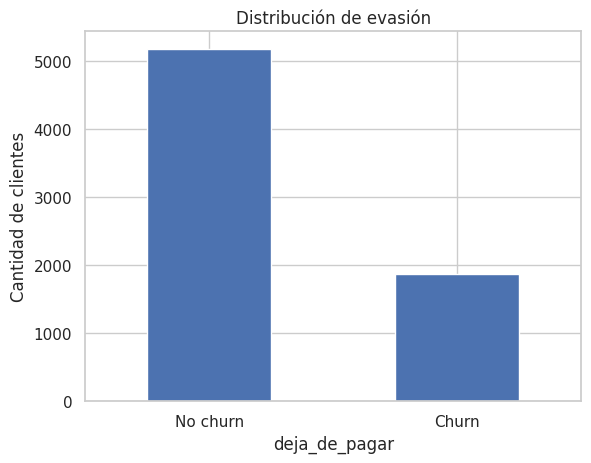

In [18]:
#18 Distribución de evasión (churn)
import matplotlib.pyplot as plt

manada_final["deja_de_pagar"].value_counts().plot(kind="bar")
plt.xticks([0,1], ["No churn","Churn"], rotation=0)
plt.title("Distribución de evasión")
plt.ylabel("Cantidad de clientes")
plt.show()


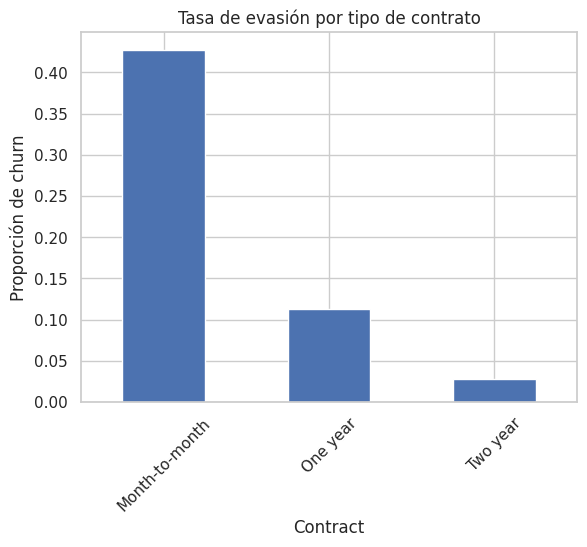

In [19]:
#19 Tasa de evasión por tipo de contrato
churn_por_contrato = manada_final.groupby("Contract")["deja_de_pagar"].mean()

churn_por_contrato.plot(kind="bar")
plt.title("Tasa de evasión por tipo de contrato")
plt.ylabel("Proporción de churn")
plt.xticks(rotation=45)
plt.show()


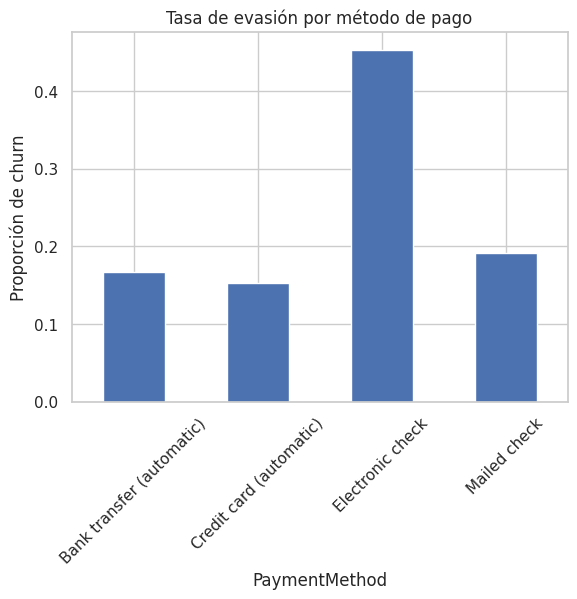

In [20]:
#20 Tasa de evasión por método de pago
churn_por_pago = manada_final.groupby("PaymentMethod")["deja_de_pagar"].mean()

churn_por_pago.plot(kind="bar")
plt.title("Tasa de evasión por método de pago")
plt.ylabel("Proporción de churn")
plt.xticks(rotation=45)
plt.show()


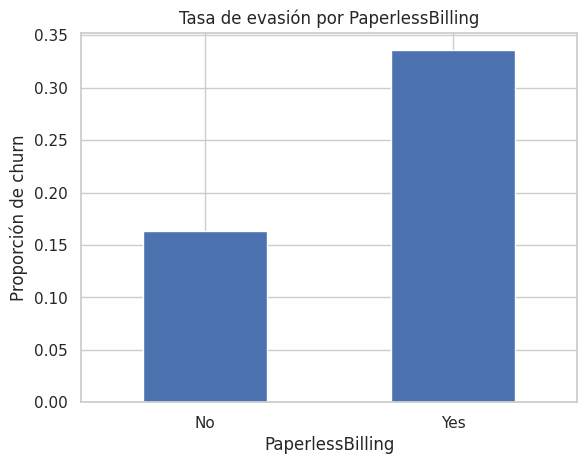

In [21]:
#21 Tasa de evasión por PaperlessBilling
churn_por_paperless = manada_final.groupby("PaperlessBilling")["deja_de_pagar"].mean()

churn_por_paperless.plot(kind="bar")
plt.title("Tasa de evasión por PaperlessBilling")
plt.ylabel("Proporción de churn")
plt.xticks(rotation=0)
plt.show()


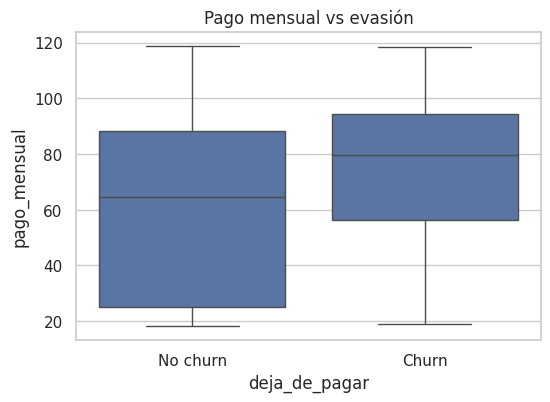

In [22]:
#22 Boxplot de pago_mensual por churn
import seaborn as sns
plt.figure(figsize=(6,4))
sns.boxplot(data=manada_final, x="deja_de_pagar", y="pago_mensual")
plt.xticks([0,1], ["No churn","Churn"])
plt.title("Pago mensual vs evasión")
plt.show()


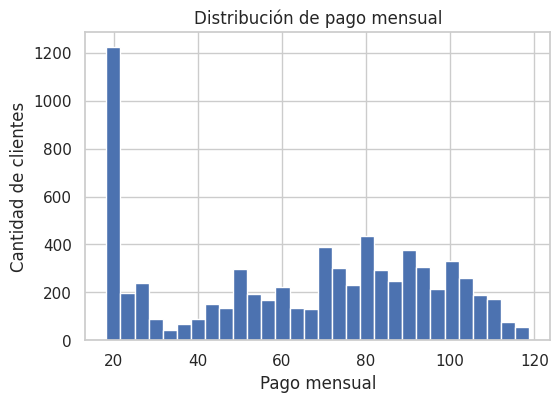

In [23]:
#23 Histograma de pago_mensual
plt.figure(figsize=(6,4))
manada_final["pago_mensual"].hist(bins=30)
plt.title("Distribución de pago mensual")
plt.xlabel("Pago mensual")
plt.ylabel("Cantidad de clientes")
plt.show()


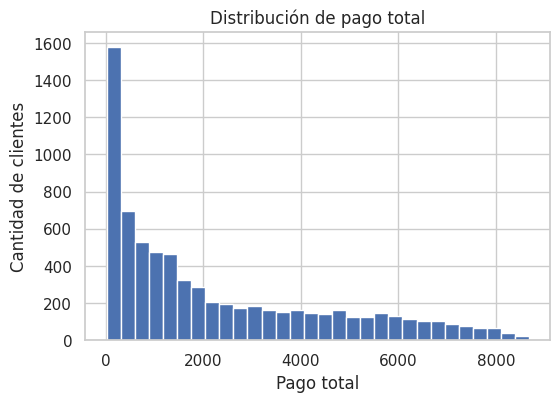

In [24]:
#24 Histograma de pago_total
plt.figure(figsize=(6,4))
manada_final["pago_total"].hist(bins=30)
plt.title("Distribución de pago total")
plt.xlabel("Pago total")
plt.ylabel("Cantidad de clientes")
plt.show()


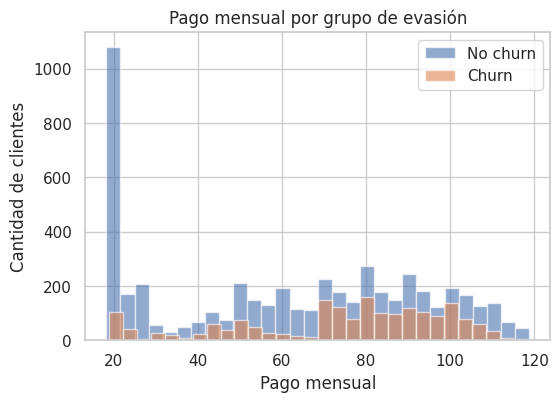

In [25]:
#25 Histograma de pago_mensual por churn
plt.figure(figsize=(6,4))
manada_final[manada_final["deja_de_pagar"] == 0]["pago_mensual"].hist(
    bins=30, alpha=0.6, label="No churn"
)
manada_final[manada_final["deja_de_pagar"] == 1]["pago_mensual"].hist(
    bins=30, alpha=0.6, label="Churn"
)
plt.title("Pago mensual por grupo de evasión")
plt.xlabel("Pago mensual")
plt.ylabel("Cantidad de clientes")
plt.legend()
plt.show()


# Análisis de evasión de clientes – Telecom X

En este proyecto analizo el churn de clientes de una empresa de telecomunicaciones llamada Telecom X  
La idea es entender por qué algunos clientes dejan el servicio y qué perfiles son más propensos a cancelar

Usé Python y pandas para trabajar con los datos  
El objetivo es dejar un dataset limpio, explorar patrones básicos y sacar algunos insights que puedan ayudar al equipo del negocio


## Extracción de datos

Los datos vienen de una API en formato JSON publicada en GitHub  
Cargué la información directamente al notebook y la convertí a un DataFrame de pandas para poder trabajar mejor con las columnas y tipos

Se descargó un archivo con la información de cada cliente  
Incluye datos de cuenta, tipo de contrato, método de pago, facturación y el estado de churn, indicando si el cliente se fue o no


## Conociendo el conjunto de datos

Revisé la estructura usando `info()` y `head()`  
El dataset tiene miles de filas, cada fila representa un cliente

Hay columnas de varios tipos  
identificador del cliente  
datos de cuenta guardados en un diccionario (`account`)  
información de churn (`Churn`)  
otros bloques como `customer`, `phone`, `internet`

A partir de `account` extraje algunas variables que me interesaban más para el análisis de evasión  
tipo de contrato (`Contract`)  
si usa facturación electrónica (`PaperlessBilling`)  
método de pago (`PaymentMethod`)  
valores de cobro (`Charges`)


## Limpieza y tratamiento de datos

Antes de analizar, fue necesario ajustar varias cosas

La columna `account` venía como un diccionario en cada fila  
A partir de ahí armé un campo intermedio (`ficha_cuenta`) para poder acceder a las claves internas de forma más cómoda

De la parte de `Charges` creé tres columnas numéricas

- `pago_mensual` (Monthly)  
- `pago_total` (Total)  
- `pago_por_dia` (pago mensual dividido entre 30)

La variable `Churn` venía con valores en texto y con distintos formatos  
La normalicé y construí una columna binaria llamada `deja_de_pagar`, donde 1 significa que el cliente se fue y 0 que se quedó

También revisé valores nulos  
En los casos donde el target estaba vacío, esas filas no se usaron para entrenar el modelo

Al final quedó un dataset más simple, con las columnas principales

- `customerID`  
- `Contract`  
- `PaperlessBilling`  
- `PaymentMethod`  
- `pago_mensual`  
- `pago_total`  
- `pago_por_dia`  
- `deja_de_pagar`


## Análisis descriptivo

Con `describe()` obtuve estadísticas básicas de las variables numéricas de pago

El pago mensual promedio se sitúa alrededor de 65, con clientes que pagan menos y otros que pagan bastante más  
El pago total muestra mucha variación, lo que indica que hay clientes nuevos con poco tiempo y otros con varios meses o años acumulados

También miré la tasa global de evasión usando `value_counts()` y la media de `deja_de_pagar`  
La proporción de clientes que abandonan el servicio ronda cerca de una cuarta parte de la base total, lo que ya es un problema relevante para la empresa


## Distribución de evasión

Para ver la distribución de churn conté cuántos clientes se quedan y cuántos se van  
El gráfico de barras muestra que la mayoría de los clientes siguen activos, pero el grupo que cancela no es pequeño

Este desbalance es importante  
la clase de “no churn” tiene más ejemplos que la de “churn”  
Esto afecta tanto la lectura de los datos como el rendimiento de los modelos, que tienden a acertar más en la clase mayoritaria


## Evasión por variables categóricas

Analicé la tasa de evasión por tipo de contrato (`Contract`)

Los contratos de tipo mensual presentan una tasa de churn bastante más alta  
Los contratos de uno y dos años muestran valores de evasión mucho menores

También revisé la variable `PaymentMethod` para ver qué pasa por método de pago

Los clientes que pagan con `Electronic check` tienen una tasa de churn más elevada  
Los métodos automáticos como tarjeta o débito y el pago con `Mailed check` tienden a mostrar menos evasión

Con `PaperlessBilling` comparé quienes usan facturación electrónica frente a los que no

Los clientes con facturación electrónica tienen un porcentaje mayor de churn  
Esto se puede relacionar con otros hábitos, como uso más digital del servicio o combinación con planes de contrato mensual  
En cualquier caso es un grupo que vale la pena observar con más detalle


## Evasión y variables numéricas

Para las variables numéricas comparé los grupos de churn y no churn

Los clientes que se van suelen tener un `pago_mensual` más alto que los que se quedan  
Sin embargo, su `pago_total` acumulado es menor, indicando que se marchan antes de acumular muchos meses en la empresa

Los boxplots e histogramas permiten ver estas diferencias en la distribución  
En el grupo de churn se observa un desplazamiento hacia valores más altos de pago mensual  
Mientras que en el pago total el grupo de evasión se concentra en montos más bajos


## Modelo simple de churn

Además del análisis exploratorio, entrené un modelo sencillo de regresión logística

Usé solo variables de cuenta

- `Contract`  
- `PaperlessBilling`  
- `PaymentMethod`

Primero realicé one hot encoding sobre estas columnas para obtener variables binarias  
Luego separé los datos en entrenamiento y prueba con una proporción estándar y estratificación por el target

El modelo alcanzó una exactitud alrededor de tres cuartas partes  
Funciona mejor para identificar clientes que no se van  
y tiene más dificultad en la clase de evasión, lo cual es normal con el desbalance de clases

Los coeficientes se alinean con lo visto en el EDA  
ciertos tipos de contrato reducen la probabilidad de churn  
algunos métodos de pago y la facturación electrónica se relacionan con mayor riesgo de salida


## Conclusiones e insights

De todo el trabajo se pueden destacar varios puntos

- La tasa de evasión no es baja, un porcentaje importante de clientes acaba cancelando  
- Los contratos mensuales concentran la mayor proporción de churn, mientras que los contratos más largos retienen mejor  
- El método de pago `Electronic check` aparece como un foco de riesgo, con una tasa de salida más alta  
- Los clientes que se van pagan más al mes pero acumulan menos pago total, lo que sugiere una posible sensibilidad al precio o insatisfacción temprana

Estos hallazgos ofrecen una primera visión de qué segmentos merecen más atención en las estrategias de retención


## Recomendaciones

Con base en los resultados, algunas posibles acciones para el negocio son las siguientes

- Revisar y reforzar las ofertas para clientes con contrato mensual, promoviendo migraciones a planes de uno o dos años con beneficios claros  
- Analizar con mayor profundidad el segmento que usa `Electronic check` y proponer alternativas de pago más estables o campañas específicas para este grupo  
- Revisar los planes con pagos mensuales más altos, evaluando si es necesario ajustar precios, agregar valor percibido o trabajar mejor la comunicación del servicio  
- Aprovechar este dataset limpio y el modelo básico como punto de partida para construir modelos predictivos más completos, incluyendo más variables de uso y tiempo de permanencia

El proyecto deja preparada una base organizada y un análisis inicial que puede ayudar al equipo de Data Science y al área de negocio a diseñar acciones para reducir la evasión de clientes
